# BaSSSh-seq — Bacteria scRNA-seq analyse
Pipeline gebaseerd op Korshoj & Kielian (2024, Nature Communications)

**Volgorde:** Import → Preprocessing (eenmalig) → Laden → Merge → HVG/PCA/BBKNN → UMAP/Leiden → Marker genen → Annotatie → CellTypist

## 1. Imports

In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import celltypist

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, frameon=False)

/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarn

## 2a. BF preprocessing — EENMALIG uitvoeren, daarna uitcommentariëren
Cutoff BF: ≥ 7 non-rRNA reads (paper Supplementary Fig. 9A)

In [ ]:
# ============================================================
# EENMALIG uitvoeren → daarna volledig uitcommentariëren
# ============================================================

#adata_bf = sc.read_h5ad("../data/BF_count_mat.h5ad")
#adata_bf.var_names_make_unique()

# # rRNA verwijdering (paper: alle rRNA genen verwijderd vóór analyse)
# # Bacteriële rRNA: 5S, 16S, 23S
#adata_bf.var["rrna"] = (
     #adata_bf.var_names.str.lower().str.startswith(("rrs", "rrl", "rrf")) |
     #adata_bf.var_names.str.lower().str.contains("rrna") |
     #adata_bf.var_names.str.lower().str.contains("16s") |
     #adata_bf.var_names.str.lower().str.contains("23s") |
     #adata_bf.var_names.str.lower().str.contains("5s_rrna")
#)
#print(f"rRNA genen gevonden (BF): {adata_bf.var['rrna'].sum()}")
#adata_bf = adata_bf[:, ~adata_bf.var["rrna"]].copy()

# # Count-filter: paper ≥ 7 non-rRNA reads voor BF → verwacht ~3680 cellen
#adata_bf.obs["total_counts"] = adata_bf.X.sum(axis=1)
#print(f"Cellen vóór filter: {adata_bf.n_obs}")
#adata_bf = adata_bf[adata_bf.obs["total_counts"] >= 7].copy()
#print(f"Cellen na filter (≥7): {adata_bf.n_obs}")  # Paper: 3680 cellen

# # Normalisatie: 10^4 counts, log+1 transform (paper Methods)
#sc.pp.normalize_total(adata_bf, target_sum=1e4)
#sc.pp.log1p(adata_bf)

# # Label voor merge
#adata_bf.obs["sample"] = "bf"

# # Opslaan
#adata_bf.write("../data/BF_gefilterd.h5ad", compression="gzip")
#print("BF opgeslagen!")

## 2b. BF laden (backed=r = minimaal RAM gebruik)

In [3]:
# Laad de voorverwerkte BF data (virtueel, weinig RAM)
adata_bf = sc.read_h5ad("../data/BF_gefilterd.h5ad", backed="r")

## 3a. Planktonic preprocessing — EENMALIG uitvoeren, daarna uitcommentariëren
Cutoff P: ≥ 28 non-rRNA reads (paper Supplementary Fig. 9A)

In [ ]:
# ============================================================
# EENMALIG uitvoeren → daarna volledig uitcommentariëren
# ============================================================
#adata_p = sc.read_h5ad("../data/P_count_mat.h5ad")
#adata_p.var_names_make_unique()

# # Zelfde rRNA verwijdering als BF
#adata_p.var["rrna"] = (
     #adata_p.var_names.str.lower().str.startswith(("rrs", "rrl", "rrf")) |
     #adata_p.var_names.str.lower().str.contains("rrna") |
     #adata_p.var_names.str.lower().str.contains("16s") |
     #adata_p.var_names.str.lower().str.contains("23s") |
     #adata_p.var_names.str.lower().str.contains("5s_rrna")
#)
#print(f"rRNA genen gevonden (P): {adata_p.var['rrna'].sum()}")
#adata_p = adata_p[:, ~adata_p.var["rrna"]].copy()

# # Count-filter: paper ≥ 28 non-rRNA reads voor Planktonic → verwacht ~4231 cellen
#adata_p.obs["total_counts"] = adata_p.X.sum(axis=1)
#print(f"Cellen vóór filter: {adata_p.n_obs}")
#adata_p = adata_p[adata_p.obs["total_counts"] >= 28].copy()
#print(f"Cellen na filter (≥28): {adata_p.n_obs}")  # Paper: 4231 cellen

# # Normalisatie
#sc.pp.normalize_total(adata_p, target_sum=1e4)
#sc.pp.log1p(adata_p)

# # Label voor merge
#adata_p.obs["sample"] = "p"

# # Opslaan
#adata_p.write("../data/P_gefilterd.h5ad", compression="gzip")
#print("Planktonic opgeslagen!")

rRNA genen gevonden (P): 20
Cellen vóór filter: 305010
Cellen na filter (≥28): 4216


... storing 'sample' as categorical


Planktonic opgeslagen!


## 3b. Planktonic laden (backed=r = minimaal RAM gebruik)

In [4]:
# Laad de voorverwerkte Planktonic data (virtueel, weinig RAM)
adata_p = sc.read_h5ad("../data/P_gefilterd.h5ad", backed="r")

## 4. Merge BF + Planktonic
Paper: cellen van beide condities gecombineerd voor BBKNN-geïntegreerde clustering

In [5]:
# Merge de twee datasets (join='inner' = alleen gedeelde genen behouden)
adata_bacteria = ad.concat(
    {"bf": adata_bf, "p": adata_p},
    label="sample",
    join="inner"
)
adata_bacteria.obs_names_make_unique()

print(f"Shape gecombineerde dataset: {adata_bacteria.shape}")
# Verwacht: ~7911 cellen (3680 BF + 4231 P), aantal genen varieert

print(f"\nSamples aanwezig: {adata_bacteria.obs['sample'].value_counts().to_dict()}")
adata_bacteria.obs.head()

Shape gecombineerde dataset: (7884, 2853)

Samples aanwezig: {'p': 4216, 'bf': 3668}


,total_counts,sample
68,14.120000,bf
96,8.770000,bf
104,16.639999,bf
107,8.700000,bf
131,9.680000,bf


## 5. HVG selectie → Scale → PCA → BBKNN
Parameters exact uit paper Methods sectie

In [6]:
# --- HVG selectie (paper: min_mean=0.00625, min_disp=0.25) ---
sc.pp.highly_variable_genes(
    adata_bacteria,
    min_mean=0.00625,
    min_disp=0.25,
    batch_key='sample'
)
print(f"Aantal highly variable genes: {adata_bacteria.var.highly_variable.sum()}")

# Raw opslaan VÓÓR HVG filtering (nodig voor marker genes & CellTypist)
adata_bacteria.raw = adata_bacteria

# Filter tot HVGs
adata_bacteria = adata_bacteria[:, adata_bacteria.var.highly_variable].copy()

# Scale & PCA (paper gebruikt n_pcs=4 in BBKNN)
sc.pp.scale(adata_bacteria, max_value=10)
sc.tl.pca(adata_bacteria, n_comps=50)

# --- BBKNN batch correctie ---
# Paper parameters: neighbors_within_batch=9, n_pcs=4
sc.external.pp.bbknn(
    adata_bacteria,
    batch_key='sample',
    neighbors_within_batch=9,
    n_pcs=4
)

print("HVG selectie + PCA + BBKNN klaar!")

Aantal highly variable genes: 1015


/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


HVG selectie + PCA + BBKNN klaar!


## 6. UMAP + Leiden clustering
Parameters exact uit paper Methods: min_dist=0.24, spread=0.21, resolution=0.205

Aantal clusters gevonden: 7
Verwacht: 7 — als dit niet klopt, pas resolution licht aan (+/- 0.01)


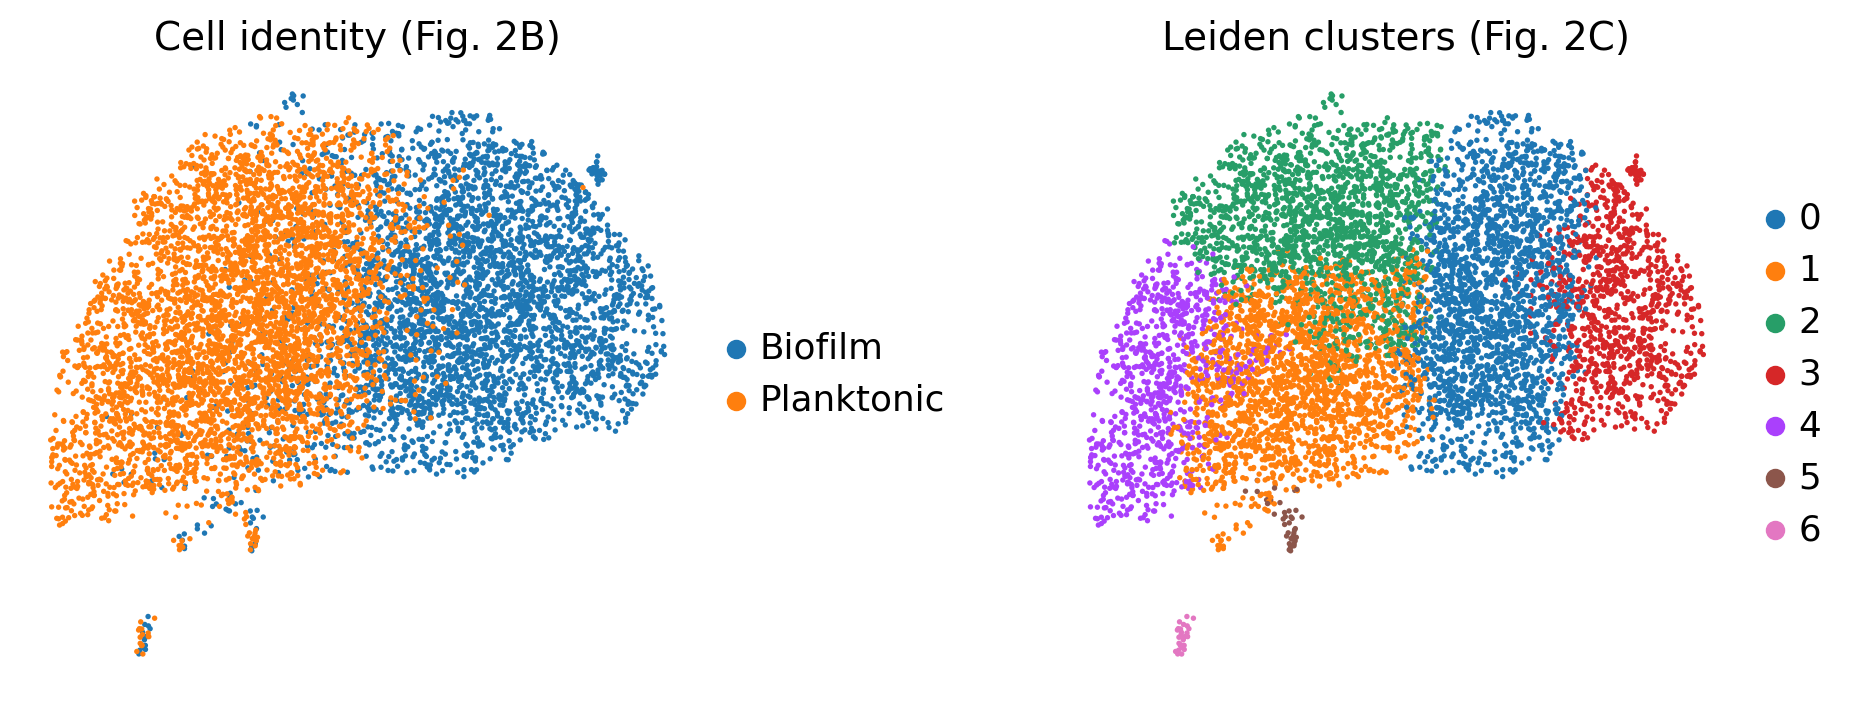

In [7]:
# UMAP (paper: min_dist=0.24, spread=0.21)
sc.tl.umap(adata_bacteria, min_dist=0.24, spread=0.21)

# Leiden clustering (paper: resolution=0.205 → geeft 7 clusters)
sc.tl.leiden(adata_bacteria, resolution=0.205)

n_clusters = adata_bacteria.obs['leiden'].nunique()
print(f"Aantal clusters gevonden: {n_clusters}")
print("Verwacht: 7 — als dit niet klopt, pas resolution licht aan (+/- 0.01)")

# Labels voor visualisatie
label_map = {'bf': 'Biofilm', 'p': 'Planktonic'}
adata_bacteria.obs['Cell identity'] = adata_bacteria.obs['sample'].map(label_map)

# UMAP plot (vergelijkbaar met Fig. 2B en 2C uit paper)
sc.pl.umap(
    adata_bacteria,
    color=['Cell identity', 'leiden'],
    title=['Cell identity (Fig. 2B)', 'Leiden clusters (Fig. 2C)'],
    wspace=0.4,
    frameon=False
)

## 7. Cluster compositie (Fig. 2D)
Stacked bar chart: verdeling BF vs Planktonic per cluster

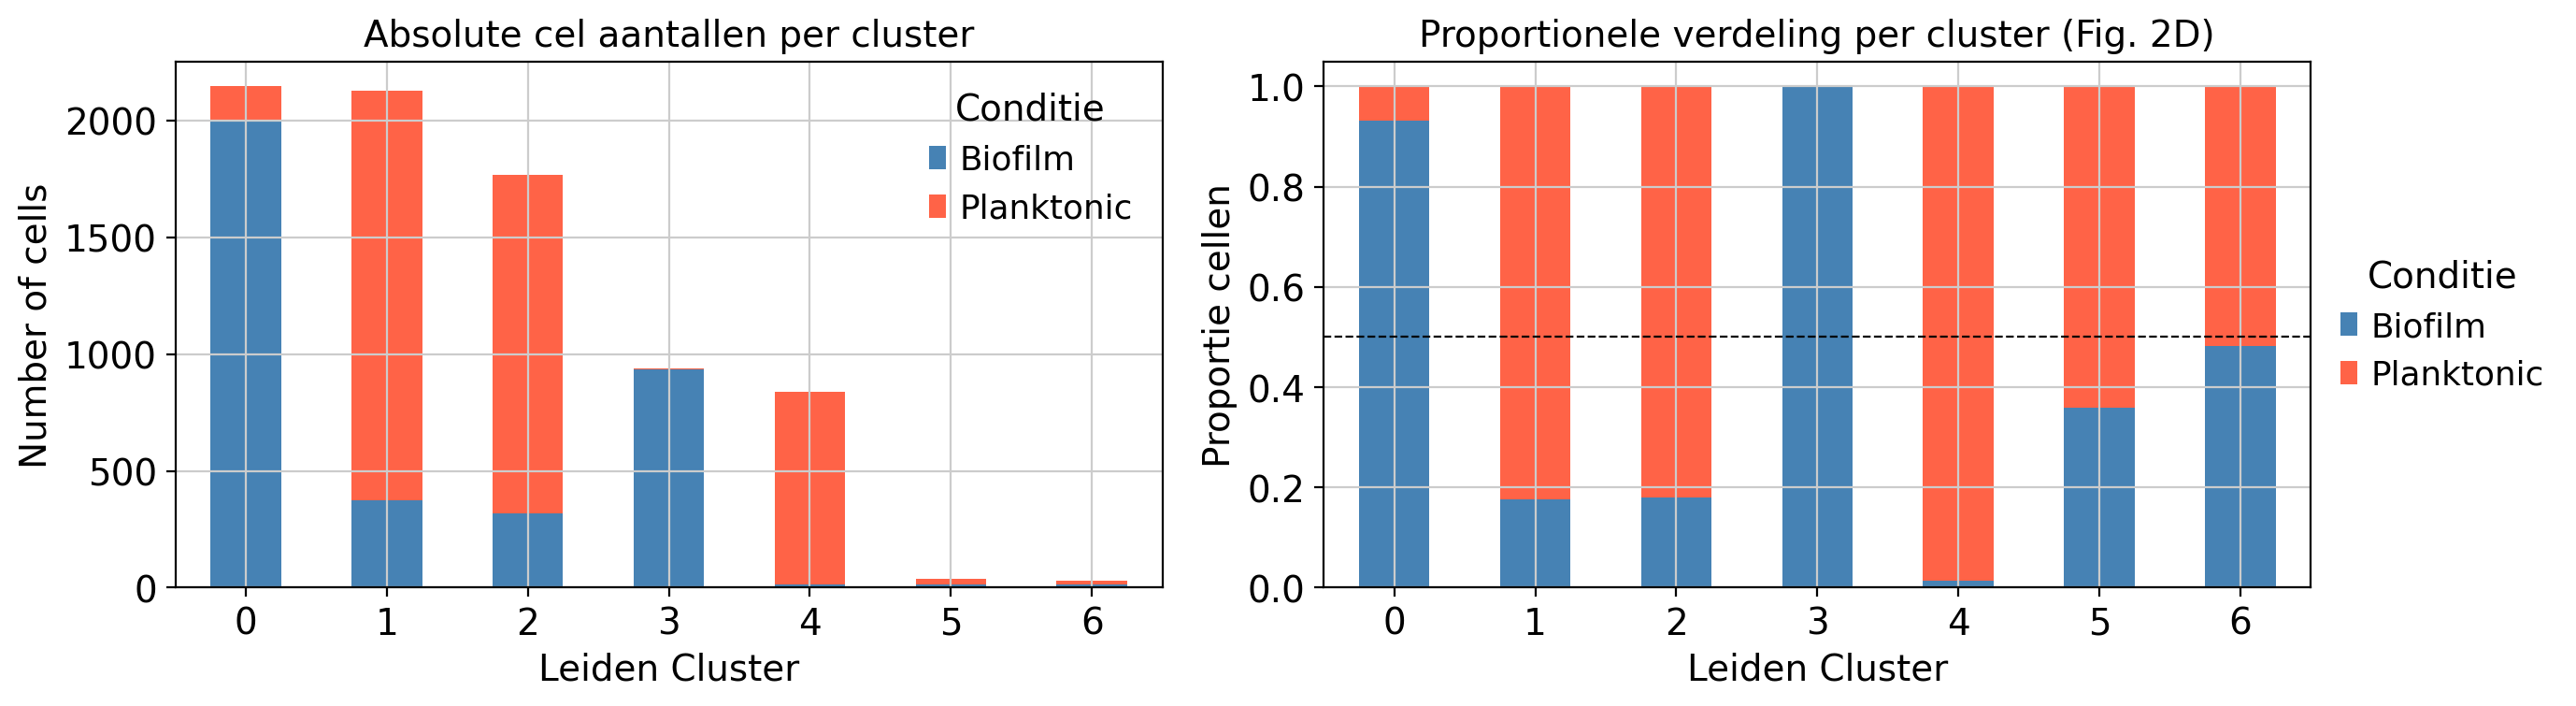

In [8]:
dist = pd.crosstab(adata_bacteria.obs['leiden'], adata_bacteria.obs['Cell identity'])
dist_norm = dist.div(dist.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
color_map = {'Biofilm': 'steelblue', 'Planktonic': 'tomato'}

# Absoluut
dist.plot(kind='bar', ax=axes[0], color=color_map, stacked=True)
axes[0].set_ylabel('Number of cells')
axes[0].set_xlabel('Leiden Cluster')
axes[0].set_title('Absolute cel aantallen per cluster')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Conditie', frameon=False)

# Genormaliseerd (zoals Fig. 2D paper)
dist_norm.plot(kind='bar', ax=axes[1], color=color_map, stacked=True)
axes[1].set_ylabel('Proportie cellen')
axes[1].set_xlabel('Leiden Cluster')
axes[1].set_title('Proportionele verdeling per cluster (Fig. 2D)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].axhline(0.5, color='black', linestyle='--', linewidth=0.8)
axes[1].legend(title='Conditie', frameon=False, loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

# Interpretatie gids:
# >80% Planktonic → Planktonic subtype
# >80% Biofilm    → Biofilm subtype
# ~50/50          → Transitional (cluster 0 in paper)

## 8. Marker genen per cluster
Paper gebruikt MAST (R); hier Wilcoxon als Python-equivalent met zelfde interpretatie:
kleine log2FC waarden zijn NIET insignificant (expliciete kanttekening in paper)

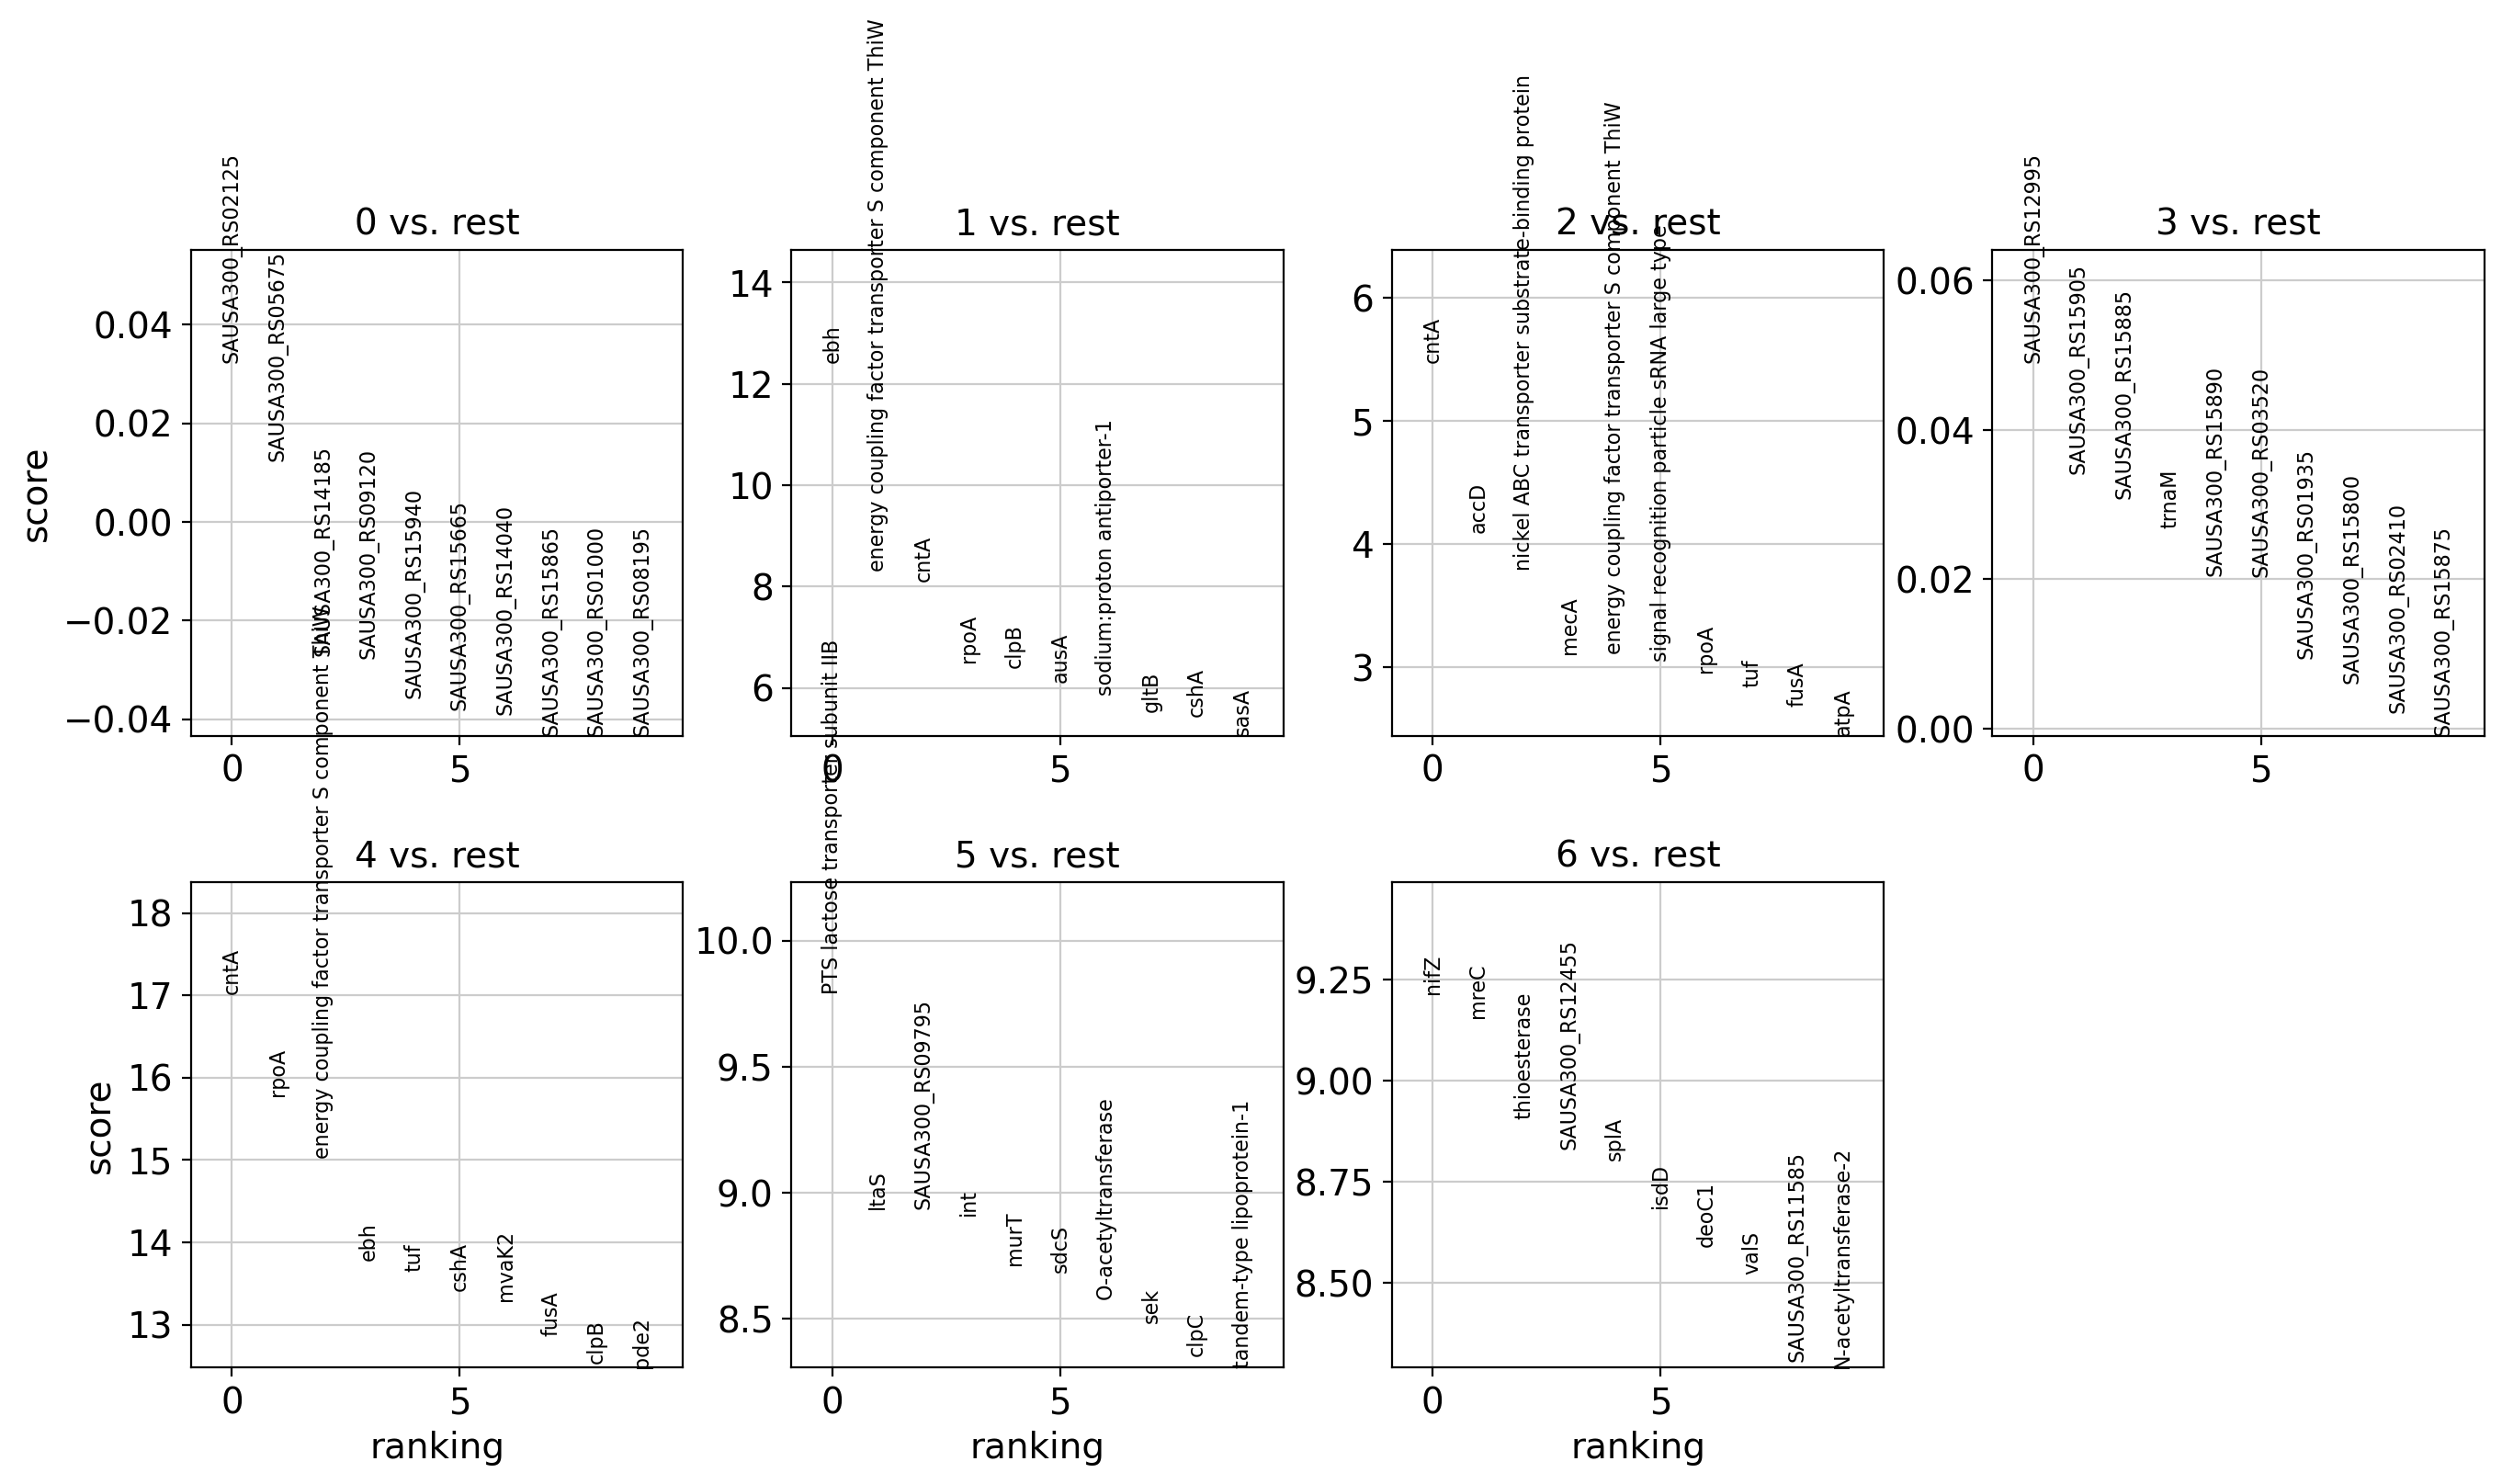

Top marker genen per cluster:
                  0                                                  1  \
0  SAUSA300_RS02125                                                ebh   
1  SAUSA300_RS05675  energy coupling factor transporter S component...   
2  SAUSA300_RS14185                                               cntA   
3  SAUSA300_RS09120                                               rpoA   
4  SAUSA300_RS15940                                               clpB   

                                                   2                 3  \
0                                               cntA  SAUSA300_RS12995   
1                                               accD  SAUSA300_RS15905   
2   nickel ABC transporter substrate-binding protein  SAUSA300_RS15885   
3                                               mecA             trnaM   
4  energy coupling factor transporter S component...  SAUSA300_RS15890   

                                                   4  \
0                       

In [9]:
sc.tl.rank_genes_groups(
    adata_bacteria,
    groupby='leiden',
    method='wilcoxon',  # beste Python-equivalent voor MAST
    use_raw=True,       # gebruik log-genormaliseerde counts vóór scaling
    pts=True            # % cellen dat gen uitdrukt
)

# Top 10 markers per cluster
sc.pl.rank_genes_groups(adata_bacteria, n_genes=10, sharey=False)

# Top 5 tabel
marker_table = pd.DataFrame(adata_bacteria.uns['rank_genes_groups']['names']).head(5)
print("Top marker genen per cluster:")
print(marker_table)

# Verwachte markers uit Table 1 van de paper (ter vergelijking)
print("\n=== Verwachte markers (paper Table 1) ===")
paper_markers = {
    "Cluster 0 (Transitional)"      : ["sasA", "pnpA", "ebh"],
    "Cluster 1 (BF Active)"         : ["citB", "ltaS", "isdH", "ebpS"],
    "Cluster 2 (P Active)"          : ["rpoB", "rpsC", "ispA"],
    "Cluster 3 (BF Virulence)"      : ["clfB", "cspB", "arcA", "fnbB"],
    "Cluster 4 (P Stationary)"      : ["qoxA", "hemY", "rplY"],
    "Cluster 5 (BF Stress)"         : ["gpmA", "polX", "fdaB", "ureA"],
    "Cluster 6 (BF Replication)"    : ["nrdE"],
}
for cluster, genes in paper_markers.items():
    print(f"  {cluster}: {genes}")

print("\nCluster compositie (% BF vs P):")
print(dist_norm.round(2))

## 9. Cluster annotatie
Pas de namen aan op basis van jouw marker tabel + compositie chart hierboven

Clusters in data:     ['0', '1', '2', '3', '4', '5', '6']
Clusters in naam dict: ['0', '1', '2', '3', '4', '5', '6']

Ongemapte cellen: 0


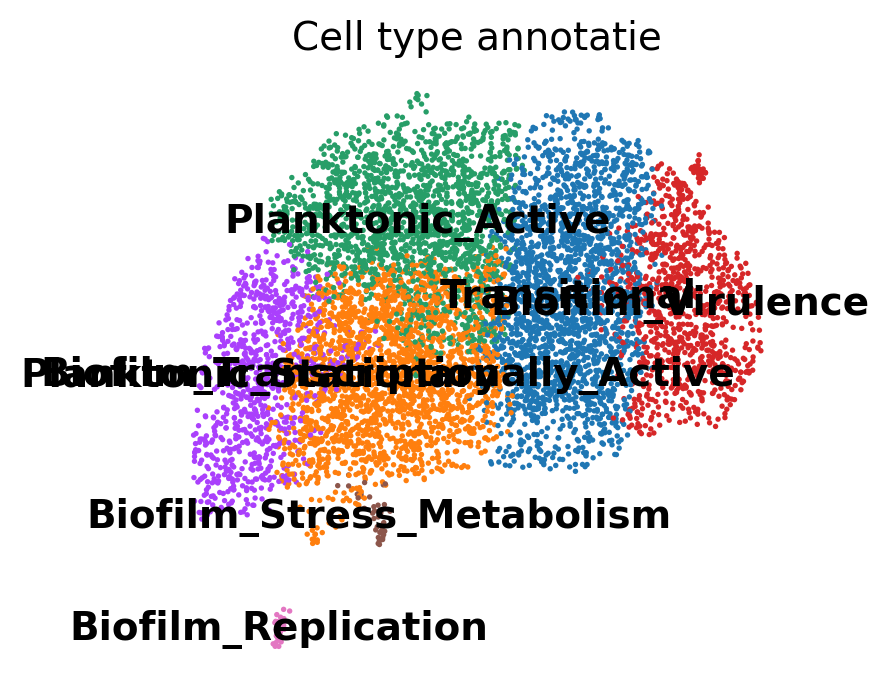

In [10]:
# STAP:
# 1. Bekijk de marker tabel hierboven
# 2. Bekijk de stacked bar chart (welke clusters zijn BF vs P gedomineerd?)
# 3. Vergelijk met de paper markers hierboven
# 4. Pas de namen hieronder aan als nodig

cluster_names = {
    '0': 'Transitional',                    # ~50/50 BF/P, sasA, pnpA
    '1': 'Biofilm_Transcriptionally_Active', # citB, ltaS, isdH
    '2': 'Planktonic_Active',               # rpoB, rpsC — meest actief
    '3': 'Biofilm_Virulence',               # clfB, fnbB, arcA
    '4': 'Planktonic_Stationary',           # qoxA, hemY
    '5': 'Biofilm_Stress_Metabolism',       # gpmA, polX, fdaB
    '6': 'Biofilm_Replication'              # nrdE
}

print(f"Clusters in data:     {sorted(adata_bacteria.obs['leiden'].unique())}")
print(f"Clusters in naam dict: {sorted(cluster_names.keys())}")

adata_bacteria.obs['cell_type'] = adata_bacteria.obs['leiden'].map(cluster_names)
print(f"\nOngemapte cellen: {adata_bacteria.obs['cell_type'].isna().sum()}")

sc.pl.umap(
    adata_bacteria,
    color='cell_type',
    legend_loc='on data',
    title='Cell type annotatie'
)

## 10. CellTypist training

In [11]:
print(f"Cellen zonder label: {adata_bacteria.obs['cell_type'].isna().sum()}")
assert adata_bacteria.obs['cell_type'].isna().sum() == 0, "Fix ontbrekende labels eerst!"

model = celltypist.train(
    adata_bacteria,
    labels='cell_type',
    feature_selection=True,
    top_genes=300
)

model.write('Staph_Aureus_BF_P_Model.pkl')
print("Model getraind en opgeslagen!")
print(f"\nTop features: {model.features}")

🍳 Preparing data before training
👀 Detected scaled expression in the input data, will try the .raw attribute
🔬 Input data has 7884 cells and 2853 genes
⚖️ Scaling input data


Cellen zonder label: 0


🏋️ Training data using SGD logistic regression
🔎 Selecting features
🧬 1427 features are selected
🏋️ Starting the second round of training
🏋️ Training data using logistic regression
✅ Model training done!


Model getraind en opgeslagen!

Top features: ['dnaA' 'dnaN' 'RNA-binding protein' ... 'noc' 'gidA' 'rpmH']
